**Importing Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

**Loading Dataset**

In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

print("x_train shape, min, max, mean, std:", x_train.shape, x_train.min(), x_train.max(), x_train.mean(), x_train.std())
print("x_test  shape, min, max, mean, std:",  x_test.shape,  x_test.min(),  x_test.max(),  x_test.mean(),  x_test.std())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape, min, max, mean, std: (60000, 28, 28, 1) 0.0 1.0 0.13066062 0.30810776
x_test  shape, min, max, mean, std: (10000, 28, 28, 1) 0.0 1.0 0.13251467 0.31048027


**Build convolutional autoencoder & Train the Model**

In [ ]:
from tensorflow.keras import layers, Model
def build_autoencoder_small():
    inp = layers.Input(shape=x_train.shape[1:])
    x = layers.Conv2D(32, 3, padding='same')(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPool2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPool2D(2, padding='same')(x)
    encoded = layers.Conv2D(128, 3, padding='same', activation='relu')(x)

    x = layers.Conv2D(128, 3, padding='same')(encoded)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(1, 3, padding='same', activation='sigmoid')(x)

    decoded = x
    model = Model(inp, decoded)
    model.compile(optimizer=Adam(1e-3), loss='mse')
    return model

autoencoder = build_autoencoder_small()
autoencoder.summary()
history = autoencoder.fit(x_train_small, x_train_small, epochs=12, batch_size=128, validation_split=0.1, verbose=2)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 334,081 (1.27 MB)

 Trainable params: 333,441 (1.27 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/12
141/141 - 16s - 112ms/step - loss: 0.0198 - val_loss: 0.1008
Epoch 2/12
141/141 - 2s - 15ms/step - loss: 0.0035 - val_loss: 0.0845
Epoch 3/12
141/141 - 2s - 15ms/step - loss: 0.0026 - val_loss: 0.0134
Epoch 4/12
141/141 - 2s - 15ms/step - loss: 0.0022 - val_loss: 0.0031
Epoch 5/12
141/141 - 2s - 14ms/step - loss: 0.0019 - val_loss: 0.0024
Epoch 6/12
141/141 - 2s - 14ms/step - loss: 0.0018 - val_loss: 0.0022
Epoch 7/12
141/141 - 2s - 14ms/step - loss: 0.0016 - val_loss: 0.0020
Epoch 8/12
141/141 - 2s - 14ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 9/12
141/141 - 2s - 15ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 10/12
141/141 - 2s - 15ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 11/12
141/141 - 2s - 14ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 12/12
141/141 - 2s - 14ms/step - loss: 0.0012 - val_loss: 0.0015


**Visual Check**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


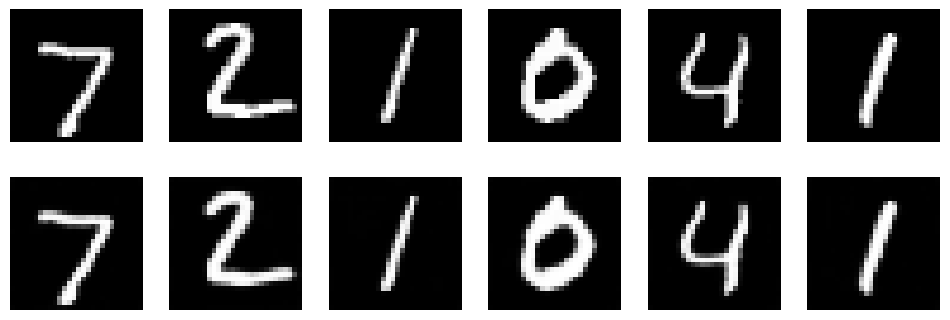

In [ ]:
decoded = autoencoder.predict(x_test[:10])
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
for i in range(6):
    plt.subplot(2,6,i+1); plt.imshow(x_test[i].squeeze(), cmap='gray', vmin=0, vmax=1); plt.axis('off')
    plt.subplot(2,6,i+1+6); plt.imshow(decoded[i].squeeze(), cmap='gray', vmin=0, vmax=1); plt.axis('off')
plt.show()
